# Dataset Analysis for the project "Fast Nano SLMs for function-calling"

**Salesforce xLAM Function Calling 60k dataset:**
https://huggingface.co/datasets/Salesforce/xlam-function-calling-60k

In [11]:
from huggingface_hub import login
from google.colab import userdata

HF_TOKEN = userdata.get('SFT_HF_TOKEN')
login(HF_TOKEN)

In [12]:
import warnings
warnings.filterwarnings("ignore")

## GPU (cuda) Info Preview

In [13]:
import torch

if torch.cuda.is_available():
    print("CUDA is available ✅")
    print("Device count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"\n--- GPU {i} ---")
        print("Name:", torch.cuda.get_device_name(i))
        print("Capability:", torch.cuda.get_device_capability(i))
        print("Total memory (GB):", torch.cuda.get_device_properties(i).total_memory / 1e9)
else:
    print("CUDA is NOT available ❌")

CUDA is available ✅
Device count: 1

--- GPU 0 ---
Name: Tesla T4
Capability: (7, 5)
Total memory (GB): 15.637086208


## Dataset Load

In [14]:
import json
import pandas as pd
from datasets import load_dataset

hf_dataset = load_dataset(
    "Salesforce/xlam-function-calling-60k",
    split="train",
    token=HF_TOKEN
)

df = hf_dataset.to_pandas()

print(df.shape)
df.head(3)

(60000, 4)


,id,query,answers,tools
0,0,Where can I find live giveaways for beta acces...,"[{""name"": ""live_giveaways_by_type"", ""arguments...","[{""name"": ""live_giveaways_by_type"", ""descripti..."
1,1,I need to understand the details of the Ethere...,"[{""name"": ""web_chain_details"", ""arguments"": {""...","[{""name"": ""peers"", ""description"": ""Retrieves a..."
2,2,What is the T3MA for 'ETH/BTC' using a 1h inte...,"[{""name"": ""t3ma"", ""arguments"": {""symbol"": ""ETH...","[{""name"": ""t3ma"", ""description"": ""Fetches the ..."


## Helper Functions

In [15]:
import re

def count_words(text):
    if text is None:
        return 0
    return len(str(text).split())

def count_chars(text):
    if text is None:
        return 0
    return len(str(text))

def safe_json_loads(x):
    if isinstance(x, list):
        return x
    try:
        return json.loads(x)
    except:
        return []

## Statistical Analysis of the Dataset

In [16]:
def extract_tool_stats(tool_list):
    total_params = 0
    total_desc_chars = 0
    total_tool_chars = len(json.dumps(tool_list))

    for tool in tool_list:
        params = tool.get("parameters", {})
        total_params += len(params)

        desc = tool.get("description", "")
        total_desc_chars += len(desc)

    return pd.Series([
        total_params,
        total_desc_chars,
        total_tool_chars
    ])

def analyze_answers(answer_list):
    num_calls = len(answer_list)

    total_arguments = 0

    for call in answer_list:
        args = call.get("arguments", {})
        total_arguments += len(args)

    return pd.Series([
        num_calls,
        total_arguments
    ])

In [17]:
def calc_dataset_stats(input_df):
  df = input_df.copy()

  # QUERIES ANALYSIS
  df["query_chars"] = df["query"].apply(count_chars)
  df["query_words"] = df["query"].apply(count_words)

  # TOOLS ANALYSIS
  df["tools_parsed"] = df["tools"].apply(safe_json_loads)
  df["num_tools"] = df["tools_parsed"].apply(len)
  df[[
      "num_parameters",
      "tool_description_chars",
      "tool_total_chars"
  ]] = df["tools_parsed"].apply(extract_tool_stats)

  # ANSWERS ANALYSIS
  df["answers_parsed"] = df["answers"].apply(safe_json_loads)
  df["answer_chars"] = df["answers"].apply(count_chars)
  df[[
      "num_function_calls",
      "num_arguments"
  ]] = df["answers_parsed"].apply(analyze_answers)

  # TOTAL INPUT CHARS
  df["total_input_chars"] = df["tool_total_chars"] + df["query_chars"]

  return df

In [18]:
%%time

df = calc_dataset_stats(df)

CPU times: user 13.9 s, sys: 365 ms, total: 14.3 s
Wall time: 14.3 s


In [19]:
eda_columns = [
    "query_chars",
    "query_words",
    "num_tools",
    "num_parameters",
    "tool_description_chars",
    "tool_total_chars",
    "answer_chars",
    "num_function_calls",
    "num_arguments",
    "total_input_chars"
]

summary = df[eda_columns].describe(percentiles=[0.5, 0.75, 0.95, 0.99, 0.999])

pd.set_option("display.max_columns", None)
styled = (
    summary.style
    .format(lambda x: f"{x:,.0f}" if float(x).is_integer() else f"{x:,.2f}")
    .background_gradient(
        cmap="Greens",
        subset=pd.IndexSlice[summary.index != "count", :]
    )
)
styled

,query_chars,query_words,num_tools,num_parameters,tool_description_chars,tool_total_chars,answer_chars,num_function_calls,num_arguments,total_input_chars
count,"60,000","60,000","60,000","60,000","60,000","60,000","60,000","60,000","60,000","60,000"
mean,111.89,19.57,2.81,6.04,223.99,"1,149.94",136.58,1.67,2.80,"1,261.83"
std,57.61,10.34,1.60,4.80,131.32,801.67,73.52,0.85,1.90,808.55
min,16,1,1,1,6,153,33,1,0,175
50%,100,17,3,5,207,994,127,2,2,"1,111"
75%,136,24,4,8,306,"1,535",168,2,4,"1,655"
95%,220,39,6,15,464,"2,698",256,3,6,"2,810"
99%,312,54.01,8,22,610,"3,668",362,4,9,"3,784"
99.9%,447.00,83,8,35,770,"5,563",628.00,8,15,"5,681.01"
max,"1,330",253,8,66,991,"9,899","4,784",52,104,"9,969"


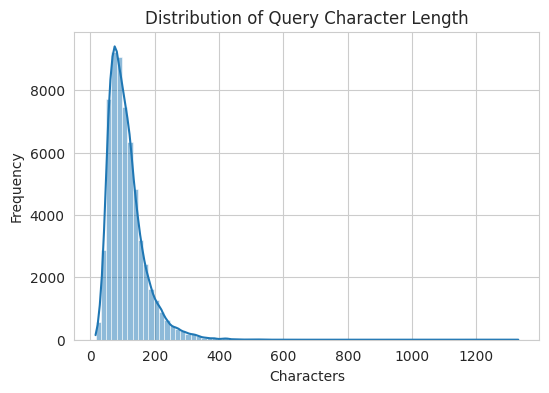

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))

sns.histplot(
    df["query_chars"],
    bins=80,
    kde=True
)

plt.title("Distribution of Query Character Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

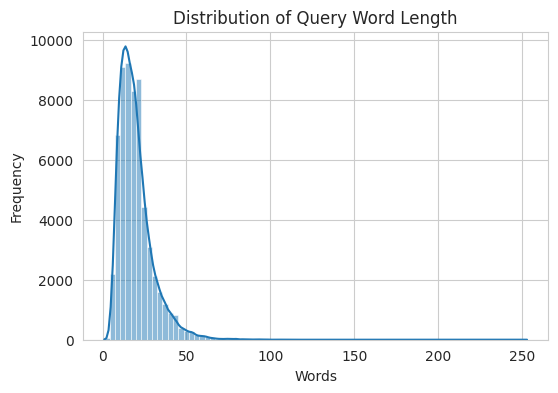

In [21]:
plt.figure(figsize=(6, 4))

sns.histplot(
    df["query_words"],
    bins=80,
    kde=True
)

plt.title("Distribution of Query Word Length")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

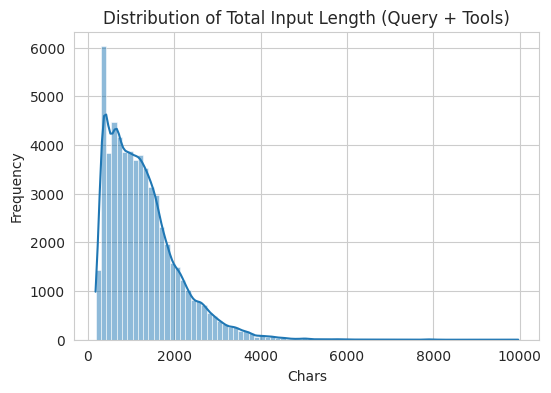

In [22]:
plt.figure(figsize=(6, 4))

sns.histplot(
    df["total_input_chars"],
    bins=80,
    kde=True
)

plt.title("Distribution of Total Input Length (Query + Tools)")
plt.xlabel("Chars")
plt.ylabel("Frequency")
plt.show()

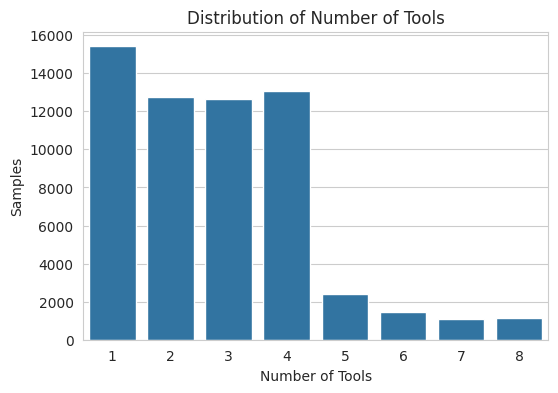

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(x=df["num_tools"])

plt.title("Distribution of Number of Tools")
plt.xlabel("Number of Tools")
plt.ylabel("Samples")
plt.show()

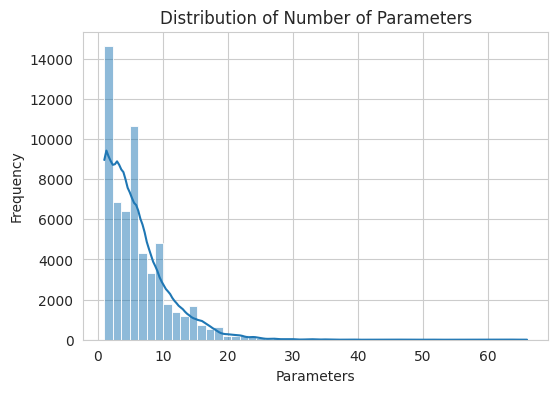

In [24]:
plt.figure(figsize=(6, 4))

sns.histplot(
    df["num_parameters"],
    bins=50,
    kde=True
)

plt.title("Distribution of Number of Parameters")
plt.xlabel("Parameters")
plt.ylabel("Frequency")
plt.show()

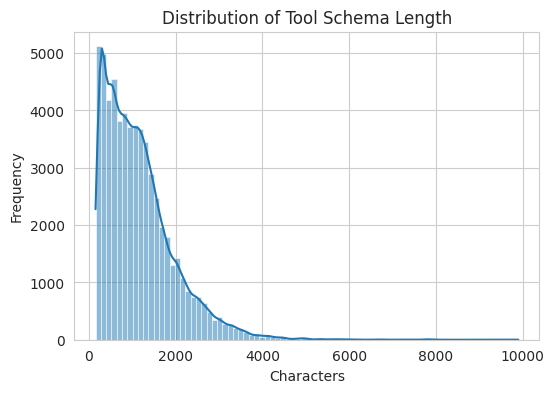

In [25]:
plt.figure(figsize=(6, 4))

sns.histplot(
    df["tool_total_chars"],
    bins=80,
    kde=True
)

plt.title("Distribution of Tool Schema Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

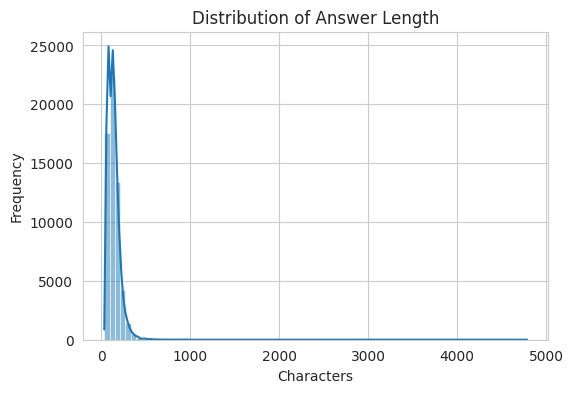

In [26]:
plt.figure(figsize=(6, 4))

sns.histplot(
    df["answer_chars"],
    bins=80,
    kde=True
)

plt.title("Distribution of Answer Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

## `max_new_tokens` param definition + Final Dataset Preparation (for SFT & testing)

[What are tokens and how to count them?](https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them) | © OpenAI Help

* Tokens are the foundational building blocks of Large Language Models (LLMs), serving as the basic units of text—such as words, characters, or subwords—that models process during both training and inference.

Helpful rules of thumb for English:
* 1 token ≈ 4 characters
* 1 token ≈ ¾ of a word
* 100 tokens ≈ 75 words
* 1–2 sentences ≈ 30 tokens
* 1 paragraph ≈ 100 tokens
* ~1,500 words ≈ 2,048 tokens

Application for tokens visualization in text: [Tiktokenizer](https://github.com/dqbd/tiktokenizer)

**For fine-tuning our SLMs for function-calling, we will use 1024 max_new_tokens** as the base value during fine-tuning, which corresponds to approximately 4096 characters. In our dataset, large total input lengths are considered outliers: more than 99.34% of model inputs (query length + tools length) are under 4096 characters, with a mean total length of 1238 characters. Therefore, we will filter the dataset accordingly and then randomly sample 10,000 examples — 9,000 for training and 1,000 for testing.

In [28]:
%%time

temp_df = df.loc[df["total_input_chars"] < 4096, "total_input_chars"]
print("Total input length is less than 4096:", round(100 * len(temp_df) / len(df), 2), "%")
print("Mean length of our target dataset:", round(temp_df.mean(), 2))

Total input length is less than 4096: 99.34 %
Mean length of our target dataset: 1237.82
CPU times: user 3.18 ms, sys: 52 µs, total: 3.23 ms
Wall time: 12.7 ms


In [29]:
def add_total_input_length(example):
    query_len = len(str(example["query"]))
    tools_len = len(str(example["tools"]))
    example["total_input_length"] = query_len + tools_len
    return example

hf_dataset = hf_dataset.map(add_total_input_length)

# keep only rows with total_input_length < 4096
filtered_dataset = hf_dataset.filter(
    lambda x: x["total_input_length"] < 4096
)

print(f"Filtered Dataset Size: {len(filtered_dataset)}")

Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/60000 [00:00<?, ? examples/s]

Filtered Dataset Size: 59606


In [30]:
RANDOM_STATE = 67 # for reproducibility

# Dataset ~ get: 10,000 samples
subset = filtered_dataset.shuffle(seed=RANDOM_STATE).select(range(10000))

# TEST SET ~ 10%
split_set = subset.train_test_split(test_size=1000, seed=RANDOM_STATE)
test_dataset = split_set['test']
sft_dataset = split_set['train'] # TRAIN SET (SFT) ~ 90%

print(f"Test Dataset: {len(test_dataset)} examples")
print(f"SFT Dataset: {len(sft_dataset)} examples")

Test Dataset: 1000 examples
SFT Dataset: 9000 examples


In [31]:
%%time

final_df = subset.to_pandas()
final_df = calc_dataset_stats(final_df)

CPU times: user 2.83 s, sys: 89.5 ms, total: 2.92 s
Wall time: 3.05 s


In [32]:
eda_columns = [
    "query_chars",
    "query_words",
    "num_tools",
    "num_parameters",
    "tool_description_chars",
    "tool_total_chars",
    "answer_chars",
    "num_function_calls",
    "num_arguments",
    "total_input_chars"
]

summary = final_df[eda_columns].describe(percentiles=[0.5, 0.75, 0.95, 0.99, 0.999])

pd.set_option("display.max_columns", None)
styled = (
    summary.style
    .format(lambda x: f"{x:,.0f}" if float(x).is_integer() else f"{x:,.2f}")
    .background_gradient(
        cmap="Greens",
        subset=pd.IndexSlice[summary.index != "count", :]
    )
)
styled

,query_chars,query_words,num_tools,num_parameters,tool_description_chars,tool_total_chars,answer_chars,num_function_calls,num_arguments,total_input_chars
count,"10,000","10,000","10,000","10,000","10,000","10,000","10,000","10,000","10,000","10,000"
mean,111.89,19.54,2.80,5.87,222.48,"1,122.90",136.57,1.67,2.79,"1,234.79"
std,58.78,10.44,1.60,4.42,129.38,743.75,71.26,0.81,1.87,751.57
min,19,4,1,1,6,153,36,1,0,175
50%,99,17,3,5,205,977,126,2,2,"1,098"
75%,135,24,4,8,305,"1,510.25",168,2,4,"1,628.25"
95%,223,40,6,15,461,"2,630",259,3,6,"2,736.10"
99%,314.01,55,8,20,600,"3,437.03",370,4,9,"3,538"
99.9%,450.01,80.00,8,25,722,"3,884.03",696.03,8,17,"4,024.00"
max,975,174,8,30,908,"4,014","1,156",14,36,"4,079"


In [36]:
# Kolmogorov–Smirnov test (KS-test)
# Interpretation: ~ Checking if this sample is a representable distribution of our original dataset
# p > 0.05 -> distributions are similar (good)
# p < 0.05 -> sample is biased (bad)

from scipy.stats import ks_2samp

def ks_test(original, sample, col):
    stat, p = ks_2samp(original[col], sample[col])
    label = "✅" if p > 0.05 else "❌"
    print(f"{col}: KS statistic={stat:.4f}, p-value={p:.4g} | {label}")

for col in eda_columns:
  ks_test(df, final_df, col)

query_chars: KS statistic=0.0077, p-value=0.6919 | ✅
query_words: KS statistic=0.0073, p-value=0.7481 | ✅
num_tools: KS statistic=0.0042, p-value=0.9984 | ✅
num_parameters: KS statistic=0.0113, p-value=0.2193 | ✅
tool_description_chars: KS statistic=0.0069, p-value=0.7994 | ✅
tool_total_chars: KS statistic=0.0107, p-value=0.2799 | ✅
answer_chars: KS statistic=0.0066, p-value=0.8469 | ✅
num_function_calls: KS statistic=0.0029, p-value=1 | ✅
num_arguments: KS statistic=0.0073, p-value=0.7506 | ✅
total_input_chars: KS statistic=0.0101, p-value=0.3439 | ✅


Two distributions come from the same underlying population; No statistically significant distribution shift;

For all features we fail to reject the null hypothesis; ~ p-values are high (0.21 -> 1.0);